In [397]:
import numpy as np
import json
from matplotlib import pyplot as plt
import matplotlib
import math

# # Load in data from JSON file Re = 400
# with open(r'C:\Users\Riley\Desktop\Code\FlowSim\Results\2025-6-2-20-28-43_Re400.0_dx0.007751937984496124_dt0.0025_t10.json','r') as file:
#     data = json.load(file)

# Load in data from JSON file Re = 1000
with open(r'C:\Users\Riley\Desktop\Code\FlowSim\Results\2025-6-2-21-47-22_Re1000.0_dx0.007751937984496124_dt0.0025_t20.json','r') as file:
    data = json.load(file)

# Load in data from JSON file Immersed Boundary Initialization
# with open(r'C:\Users\Riley\Desktop\Code\FlowSim\Results\2025-6-1-16-37-23_Re200.0_dx0.009900990099009901_dt0.0025_t0.01.json','r') as file:
#     data = json.load(file)

#Load in data from JSON file Re = 7500
# with open(r'C:\Users\Riley\Desktop\Code\FlowSim\Results\2025-6-2-18-55-44_Re3200.0_dx0.007751937984496124_dt0.00025_t8.json','r') as file:
#     data = json.load(file)

#print(data['U'])


In [398]:
# Initial X and Y
nx = data['nx']
dx = data['dx']
x_max = nx*dx
x = np.linspace(0,x_max,nx+1)

ny = data['ny']
dy = data['dy']
y_max = ny*dy
y = np.linspace(0,y_max,ny+1)

X, Y = np.meshgrid(x, y, indexing='ij')
U = np.array(data['U'])
V = np.array(data['V'])

V2 = np.zeros((nx+1, ny+1))
for i in range(len(V)):
    for j in range(len(V[0])):
        V2[i,j] = -V[-i-1,j]

U2 = np.zeros((nx+1, ny+1))
for i in range(len(U)):
    for j in range(len(U[0])):
        U2[i,j] = U[-i-1,j]

# print(V)
# print(V2)
V = V2
U = U2

# print(np.shape(X))
# print(np.shape(U))

# print(np.shape(Y))
# print(np.shape(V))

# print(type(X))
# print(type(U))

# print(type(Y))
# print(type(V))

# print(X)
# print(U)

In [399]:
# Test data
# X, Y = np.meshgrid(np.arange(0,1,1/5), np.arange(0,1.5,1.5/5), indexing='ij')
# U = np.ones((5, 5))
# V = np.zeros((5,5))

# print(np.shape(X))
# print(np.shape(U))
# print(type(X))
# print(type(U))
# print(X)
# print(U)

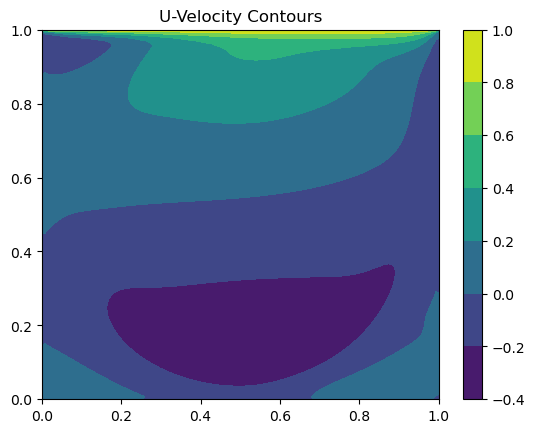

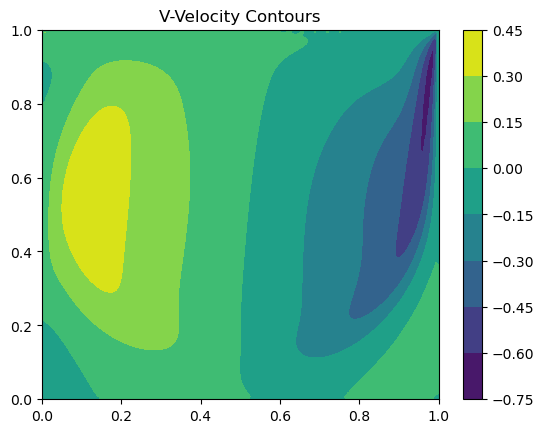

In [400]:
# Plot U velocities
plt.contourf(X, Y, U)
plt.title('U-Velocity Contours')
plt.colorbar()

plt.figure()
plt.contourf(X, Y, V)
plt.title('V-Velocity Contours')
plt.colorbar()
plt.show()

8000
Final Error = 0.09339239933690494


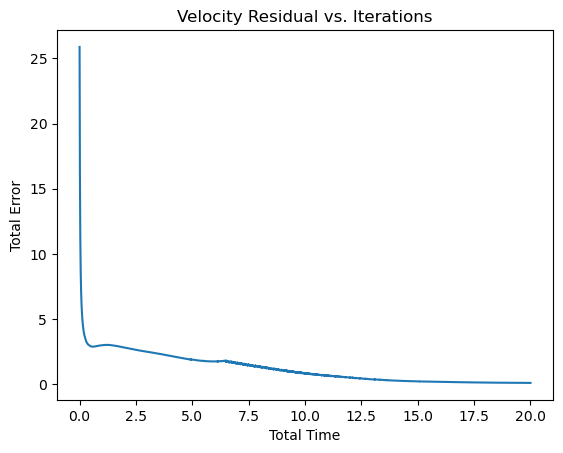

In [402]:
# Plot Relative velocity error

# Calulate lsit of timesteps
timesteps = data['total time']/data['dt']
print(int(timesteps))
times = np.linspace(0, data['total time'], int(timesteps))

print(f'Final Error = {data['Error'][-1]}')

plt.figure()
plt.plot(times, data['Error'])
plt.title('Velocity Residual vs. Iterations')
plt.xlabel('Total Time')
plt.ylabel('Total Error')
plt.show()

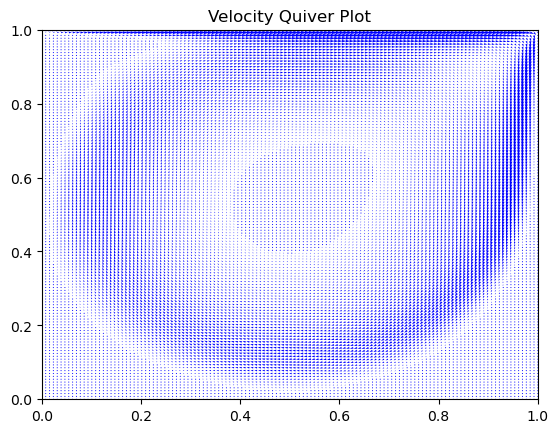

In [403]:
# Quiver Plots

plt.quiver(X, Y, U, V, color='blue')
plt.title('Velocity Quiver Plot')
plt.xlim(0,x_max)
plt.ylim(0,y_max)
plt.show()

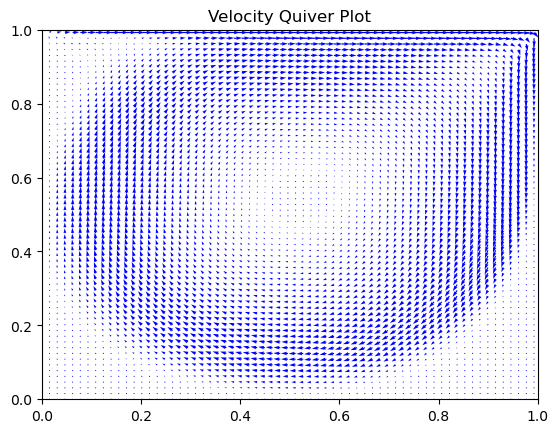

In [404]:
# Plot reduce quiver

order = 2

X_reduced = []
for i in range(0, len(X), order):
    X_reduced.append(X[i][::order])

Y_reduced = []
for i in range(0, len(Y), order):
    Y_reduced.append(Y[i][::order])

U_reduced = []
for i in range(0, len(U), order):
    U_reduced.append(U[i][::order])

V_reduced = []
for i in range(0, len(V), order):
    V_reduced.append(V[i][::order])


plt.quiver(X_reduced, Y_reduced, U_reduced, V_reduced, color='blue')
plt.title('Velocity Quiver Plot')
plt.xlim(0,x_max)
plt.ylim(0,y_max)
plt.show()


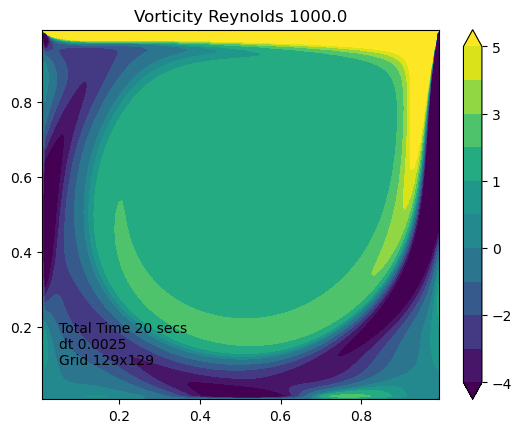

In [405]:
# Compute vorticity

vorticity = np.zeros((nx+1, ny+1))
w_x = np.linspace(dx,x_max-dx,nx+1)
w_y = np.linspace(dy,y_max-dy,ny+1)
w_X, w_Y = np.meshgrid(w_x, w_y, indexing='ij') 

for i in range(1, len(U)):
    for j in range(1, len(U[0])):
        vorticity[i,j] = -(-V[i-1,j] + V[i,j])/(dx) + (-U[i,j-1] + U[i,j])/(dy)

vort2 = np.gradient(V, axis=0) - np.gradient(U, axis=1)

# norm=matplotlib.colors.LogNorm()
N = 6
plt.contourf(w_X, w_Y, vorticity, [-4, -3, -2, -1, 0, .5, 1, 2, 3 ,4, 5], extend='both')
plt.colorbar()
plt.title(f'Vorticity Reynolds {data['Reynolds']}')
plt.annotate(f'Total Time {data['total time']} secs\ndt {data['dt']}\nGrid {nx}x{ny}', (.05,.1))
plt.show()


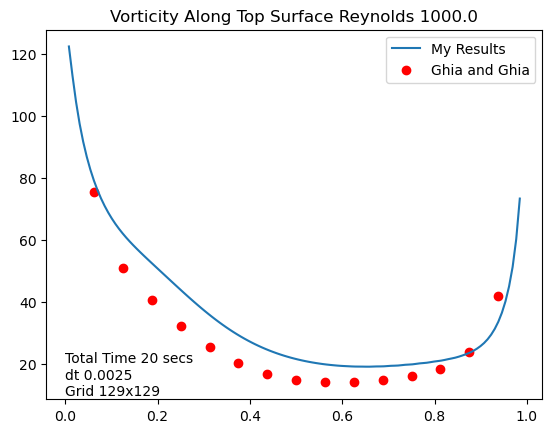

In [409]:
### Plot vorticity along Top surface
g_xloc = [.0625, .125, .1875, .25, .3125, .3750, .4375, .5, .5625, .6250, .6875, .75, .8125, .875, .9375]
g_vort_400 = [53.6863, 34.6351, 26.5825, 21.0985, 16.890, 13.7040, 11.4537, 10.0545, 9.38889, 9.34599, 9.88979, 11.2018, 13.9068, 19.6859, 35.0773]
g_vort_1000 = [75.5980, 51.0557, 40.5437, 32.2953, 25.4341, 20.2666, 16.8350, 14.8901, 14.0928, 14.1374, 14.8061, 16.0458, 18.3120, 23.8707, 42.1124]

top_vort = []
for list in vorticity:
    top_vort.append(list[-1])

x_loc = []
for list in X:
    x_loc.append(list[-1])

plt.plot(x_loc[1:-2], top_vort[1:-2])
if data['Reynolds'] == 400:
    plt.scatter(g_xloc, g_vort_400, color='red')
elif data['Reynolds'] == 1000:
    plt.scatter(g_xloc, g_vort_1000, color='red')
plt.legend(['My Results', 'Ghia and Ghia'])
plt.title(f'Vorticity Along Top Surface Reynolds {data['Reynolds']}')
plt.annotate(f'Total Time {data['total time']} secs\ndt {data['dt']}\nGrid {nx}x{ny}', (0,10))
plt.show()




[]

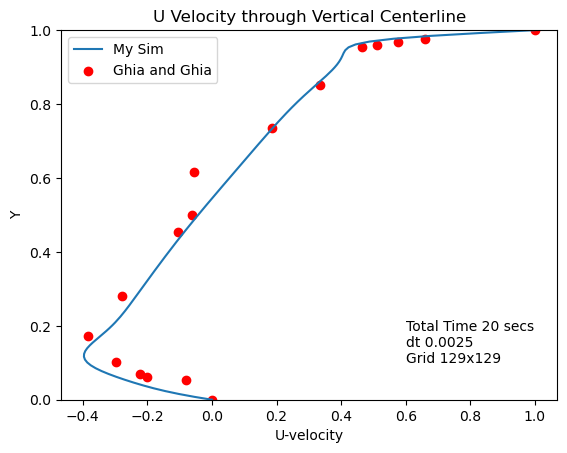

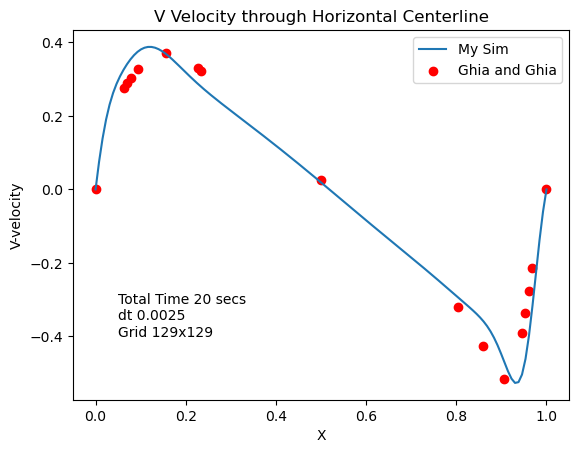

In [407]:
## Ghia and Ghia data Re 400
height = [0, .0547, .0625, .0703, .1016, .1719, .2813, .4531, .5, .6172, .7344, .8516, .9531, .9609, .9688, .9766, 1]
x_g = [0, .0625, .0703, .0781, .0938, .1563, .2266, .2344, .5, .8047, .8594, .9063, .9453, .9531, .9609, .9688, 1]


u_g_400 = [0, -.08186, -.09266, -.10338, -.14612, -.24299, -.32726, -.17119, -.11477, .02135, .16256, .29093, .55892, .61756, .68439, .75837, 1]
v_g_400 = [0, .1836, .19713, .20920, .22965, .28124, .30203, .30174, .05186, -.38598, -.44993, -.23827, -.22847, -.19254, -.15663, -.12146, 0]

## Ghia and Ghia data Re 1000
u_g_1000 = [0, -.08186, -.20196, -.22220, -.29730, -.38289, -.27805, -.10648, -.06080, -.05702, .18719, .33304, .46604, .51117, .57492, .65928, 1]
v_g_1000 = [0, .27458, .29012, .30353, .32627, .37095, .33075, .32235, .02526, -.31966, -.42665, -.51550, -.39188, -.33714, -.27669, -.21388, 0]

index = math.floor(nx/2)

# Get u velocities down the centerline
u_center = []
for point in U[index]:
    u_center.append(point)

# Get v-velocities across the centerline
v_center = []
for list in V:
    v_center.append(list[index])

x_loc = []
for list in X:
    x_loc.append(list[index])



# print(X[50])
# print(Y[50])

#print(x_loc)
# print( v_center)
plt.plot(u_center, Y[index])

if data['Reynolds'] == 400:
    plt.scatter(u_g_400, height,color='red')
elif data['Reynolds'] == 1000:
    plt.scatter(u_g_1000, height,color='red')
plt.legend(['My Sim', 'Ghia and Ghia'])
plt.ylim(0,y_max)
plt.ylabel('Y')
plt.xlabel('U-velocity')
plt.title('U Velocity through Vertical Centerline')
plt.annotate(f'Total Time {data['total time']} secs\ndt {data['dt']}\nGrid {nx}x{ny}', (.6,.1))

plt.figure()
plt.plot(x_loc, v_center)
if data['Reynolds'] == 400:
    plt.scatter(x_g, v_g_400, color='red')
elif data['Reynolds'] == 1000:
    plt.scatter(x_g, v_g_1000, color='red')
plt.legend(['My Sim', 'Ghia and Ghia'])
plt.title('V Velocity through Horizontal Centerline')
plt.ylabel('V-velocity')
plt.xlabel('X')
plt.annotate(f'Total Time {data['total time']} secs\ndt {data['dt']}\nGrid {nx}x{ny}', (.05,-.4))
plt.plot()


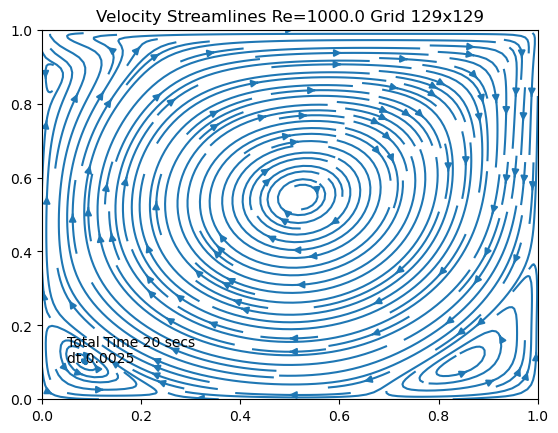

In [408]:
U_t = np.transpose(U)
V_t = np.transpose(V)

for i in range(len(V_t)):
    for j in range(len(V_t[0])):
        if i == 0 or i==nx+1 or j==0 or j==ny+1:
            V_t[i,j] = 0


X_t, Y_t = np.meshgrid(x, y)

# Plot Velocity contours

plt.streamplot(X_t, Y_t, U_t, V_t, density=2)
plt.xlim(0,x_max)
plt.ylim(0,y_max)
plt.title(f'Velocity Streamlines Re={data['Reynolds']} Grid {nx}x{ny}')
plt.annotate(f'Total Time {data['total time']} secs\ndt {data['dt']}', (.05,.1))
plt.show()

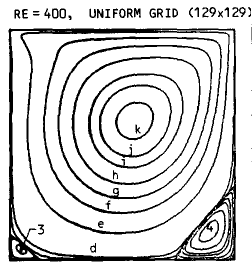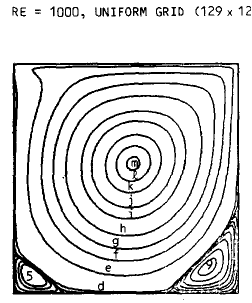

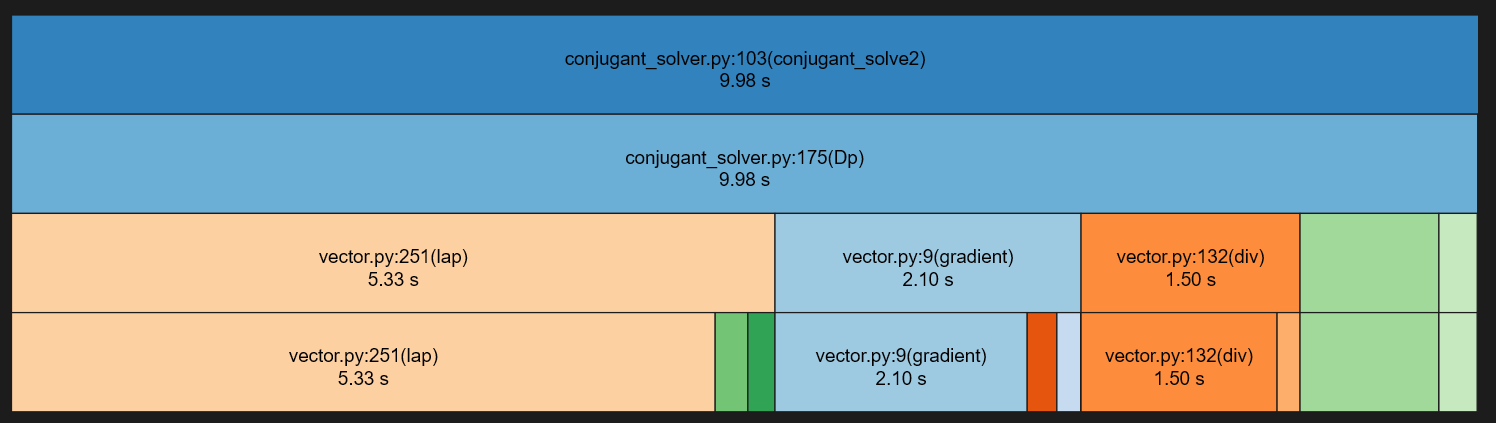